# GeoPandas

As principais bibliotecas python que são utilizadas para geo processamento são:
* **geopandas** = trabalha com dados geoespaciais como se fossem tabelas (dataframes)
* **shapely** = é para criar e manipular geometrias (pontos, linhas e polígonos)
* **fiona** = é para ler e escrever arquivos geoespaciais (shapefile, geojson, etc)
* **gdal/rastreio** = é para trabalhar com dados raster (imagens de satélite)
* **folium/leafmap** = é para criar dados interativos para a web

### Revisão pandas

O ponto mais importante para o geopandas que devemos relembrar é que:
* Um dataframe é uma tabela com linhas e colunas, como uma planilha.
* Cada coluna do dataframe é uma serie. Desse modo, um conjunto de series é um dataframe.


In [1]:
import pandas as pd

dados = {
    "cidade": ["São Paulo", "Rio de Janeiro", "Belo Horizonte", "Salvador", "Brasília"],
    "populacao": [12300000, 6700000, 2500000, 2900000, 3000000],
    "latitude": [-23.55, -22.91, -19.92, -12.97, -15.78],
    "longitude": [-46.63, -43.20, -43.94, -38.50, -47.93]
}

data_cidades = pd.DataFrame(dados)
data_cidades

,cidade,populacao,latitude,longitude
0,São Paulo,12300000,-23.55,-46.63
1,Rio de Janeiro,6700000,-22.91,-43.20
2,Belo Horizonte,2500000,-19.92,-43.94
3,Salvador,2900000,-12.97,-38.50
4,Brasília,3000000,-15.78,-47.93


Algumas das operações básicas:

In [2]:
print("O número de linhas e colunas: ", data_cidades.shape)
print("O nome das colunas:", list(data_cidades.columns))
print("Os tipos de dados:")
print(data_cidades.dtypes)
print("As primeiras 3 linhas são:")
data_cidades.head(3)


O número de linhas e colunas:  (5, 4)
O nome das colunas: ['cidade', 'populacao', 'latitude', 'longitude']
Os tipos de dados:
cidade        object
populacao      int64
latitude     float64
longitude    float64
dtype: object
As primeiras 3 linhas são:


,cidade,populacao,latitude,longitude
0,São Paulo,12300000,-23.55,-46.63
1,Rio de Janeiro,6700000,-22.91,-43.20
2,Belo Horizonte,2500000,-19.92,-43.94


Em relação aos dados geoespaciais, como coordenadas de pontos de coleta de água em um rio, tem-se:

In [3]:
csv_path = '/content/dados/pontos_coleta.csv'

df_coleta = pd.read_csv(csv_path)
df_coleta

,id,data,parametro,valor,x,y
0,1,2024-01-15,pH,6.8,-46.63,-23.55
1,2,2024-01-15,turbidez,12.3,-46.64,-23.56
2,3,2024-01-15,pH,7.1,-46.65,-23.55
3,4,2024-01-16,oxigenio,5.2,-46.62,-23.54
4,5,2024-01-16,pH,6.9,-46.66,-23.57
5,6,2024-01-16,turbidez,8.7,-46.63,-23.56


### GeoDataFrame

Para transformar os dados da coluna x e y em dados espaciais é utilizado a função **points_from_xy** do GeoPandas. Ela cria uma coluna de geometrias do tipo ponto a partir de colunas de ***longitude (x)*** e ***latitude (y)***.



In [4]:
import geopandas as gpd
from shapely.geometry import Point

gdf = gpd.GeoDataFrame(
    df_coleta,
    geometry=gpd.points_from_xy(df_coleta["x"], df_coleta["y"]),
    )

print("Tipo de objeto:", type(gdf))
print("Geomtrias criadas:")
gdf

Tipo de objeto: <class 'geopandas.geodataframe.GeoDataFrame'>
Geomtrias criadas:


,id,data,parametro,valor,x,y,geometry
0,1,2024-01-15,pH,6.8,-46.63,-23.55,POINT (-46.63 -23.55)
1,2,2024-01-15,turbidez,12.3,-46.64,-23.56,POINT (-46.64 -23.56)
2,3,2024-01-15,pH,7.1,-46.65,-23.55,POINT (-46.65 -23.55)
3,4,2024-01-16,oxigenio,5.2,-46.62,-23.54,POINT (-46.62 -23.54)
4,5,2024-01-16,pH,6.9,-46.66,-23.57,POINT (-46.66 -23.57)
5,6,2024-01-16,turbidez,8.7,-46.63,-23.56,POINT (-46.63 -23.56)


O atributo CRS (Coordinate Reference System) é utilizado para dizer ao python onde e como as coordenadas se relacionam com locais reais da terra.

Existem dois tipos principais de CRS:
* **geographic coordinate system (gcs)** = usa um modelo 3d esferico para localizar latitude e longitude, e é calculado em graus.
* **projected coordinate systems (pcs)** = usa fórmulas matemáticas para reduzir o mapa 3d da terra em um mapa 2d, e é medido em metros ou pés.

Visto que o objetivo é realizar mapeamento de latitudes e longitudes os dois crs que podem ser utilizados é **EPSG:4326** (The Standard: WGS 84) e **EPSG:2857**.


In [5]:
print(gdf.crs)

None


In [6]:
gdf = gdf.set_crs(epsg=4326)
print(gdf.crs)

EPSG:4326


Explorando o dataframe criado

In [7]:
gdf.columns

Index(['id', 'data', 'parametro', 'valor', 'x', 'y', 'geometry'], dtype='object')

In [8]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   id         6 non-null      int64   
 1   data       6 non-null      object  
 2   parametro  6 non-null      object  
 3   valor      6 non-null      float64 
 4   x          6 non-null      float64 
 5   y          6 non-null      float64 
 6   geometry   6 non-null      geometry
dtypes: float64(3), geometry(1), int64(1), object(2)
memory usage: 468.0+ bytes


In [9]:
gdf.geometry

,geometry
0,POINT (-46.63 -23.55)
1,POINT (-46.64 -23.56)
2,POINT (-46.65 -23.55)
3,POINT (-46.62 -23.54)
4,POINT (-46.66 -23.57)
5,POINT (-46.63 -23.56)


In [10]:
print(gdf.geom_type)

0    Point
1    Point
2    Point
3    Point
4    Point
5    Point
dtype: object


Para saber quais são os limites da área de coordenadas:

In [11]:
print("Limites (bounds) de todas as geometrias:")
print(gdf.total_bounds)

Limites (bounds) de todas as geometrias:
[-46.66 -23.57 -46.62 -23.54]


É importante destacar que em GIS a convenção é **(longitude, latitude) = (x, y)**. Sendo que a *latitude é y (Norte/Sul)* e a *longitude é x (Leste/Oeste)*.

### Sistemas de Referência de Coordenadas (CRS)


Utilizar coordenadas em um CRS é ineficaz, pois elas são apenas números. O CRS define como os números se relacionam com a superfície da Terra. Existem dois tipos fundamentais:

* ***geográfico*** = coordenadas angulares (latitude/longitude) sobre um modelo esférico da Terra. é medido em graus.  Exemplo:  **EPSG: 4326 (WGS 84)**
* ***projetado*** = coordenadas planas (x, y) em metros, que é o resultado de projetar a esfera em um plano. é medido em metros. Exemplo:  **EPSG: 31983 (SIRGAS 2000 / UTM 23S)**

ps: SIRGAS2000 é o sistema geodésico de referência oficial do Brasil.

A principal diferença entre o SIRGAS2000 e o WGS84 é que este é utilizado por aparelhos GPS e mesmo que aquele seja praticamente igual ao WGS84 ele é ajustado especificamente para a placa tectônica da América do Sul.

In [12]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Transformando em **SIRGAS2000**

In [13]:
gdf.to_crs("EPSG:4989")

,id,data,parametro,valor,x,y,geometry
0,1,2024-01-15,pH,6.8,-46.63,-23.55,POINT (-46.63 -23.55)
1,2,2024-01-15,turbidez,12.3,-46.64,-23.56,POINT (-46.64 -23.56)
2,3,2024-01-15,pH,7.1,-46.65,-23.55,POINT (-46.65 -23.55)
3,4,2024-01-16,oxigenio,5.2,-46.62,-23.54,POINT (-46.62 -23.54)
4,5,2024-01-16,pH,6.9,-46.66,-23.57,POINT (-46.66 -23.57)
5,6,2024-01-16,turbidez,8.7,-46.63,-23.56,POINT (-46.63 -23.56)


A diferença entre as funções *set_crs* e *to_crs*

* `.set_crs()` → declara qual CRS os dados já estão usando ou seja não altera as coordenadas.
* `.to_crs()` → converte as coordenadas para outro CRS ou seja os dados são alterados.

### Visualizações

O geopandas permite usar o matplotlib para plotar geometrias diretamente:

<Axes: >

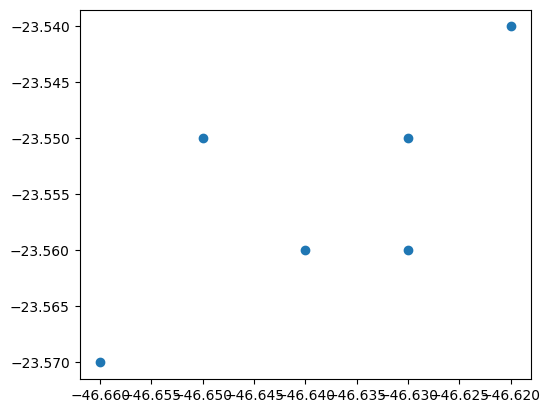

In [14]:
gdf.plot()

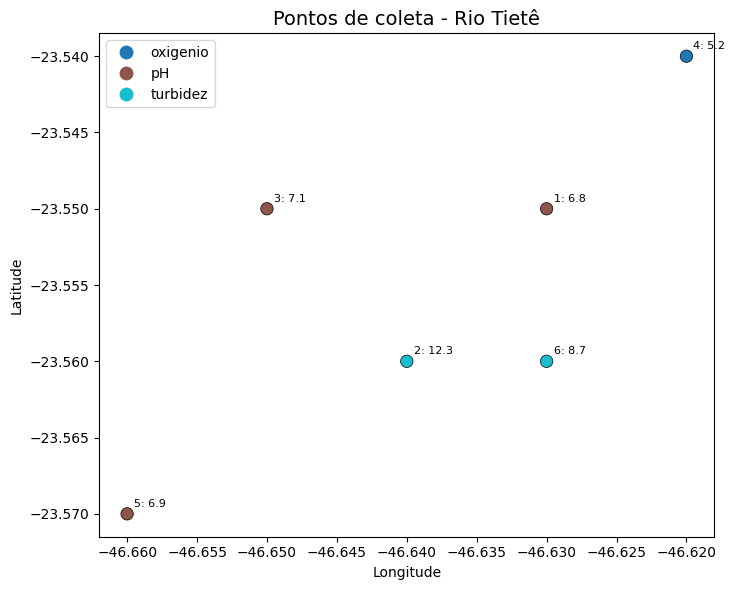

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

gdf.plot(
    ax=ax,
    column="parametro",
    legend=True,
    markersize=80,
    edgecolor="black",
    linewidth=0.5,
)

for idx, row in gdf.iterrows():
  ax.annotate(
      f"{row["id"]}: {row["valor"]}",
      (row.geometry.x, row.geometry.y),
      xytext=(5, 5),
      textcoords="offset points",
      fontsize=8,
  )

ax.set_title("Pontos de coleta - Rio Tietê", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

### Exportando os dados

In [16]:
import os

os.makedirs("saida", exist_ok=True)

#exportando em um formato classico
gdf.to_file("saida/pontos_coleta.shp")
print("Shapefile salvo: saida/pontos_coleta.shp")


#exportando em um formato que interage com o frontend -- javascript
gdf.to_file("saida/pontos_coleta.geojson", driver="GeoJSON")
print("GeoJSON salvo: saida/pontos_coleta.geojson")

#exportando em um formato multidimensional
gdf.to_file("saida/pontos_coleta.gpkg", driver="GPKG")
print("GeoPackage salvo: saida/pontos_coleta.gpkg")



Shapefile salvo: saida/pontos_coleta.shp
GeoJSON salvo: saida/pontos_coleta.geojson
GeoPackage salvo: saida/pontos_coleta.gpkg


Resumo rápido sobre os formatos:

* shapefile (.shp) = é o formato mais antigo e difundido, fundado pela arcgis, e é limitado a 10 caracteres no nome de colunas.
* geojson (.geojson) = é baseado em JSON, sendo ideal para web e APIs
* geopackage (.gpkg) = é o padrão moderno da ogc, como é baseado em sqlite suporta múltiplas camadas num só arquivo.

ps: **em projetos novos o geopackage** é mais recomendado, já em **projetos que interagem com sistemas legados o ideal é o shapefile** e **para aplicações web o geojson**.

### Integrando Shapely e GeoPandas

Visto que o Shapely cria e manipula geometrias e o GeoPandas organiza geometrias em dataframes, a coluna geometry de um geodataframe é composta por objetos shapely.

Desse modo, vamos criar um geodataframe a partir de geometrias criadas no shapely.

In [17]:
from shapely.geometry import Polygon, box

zonas = gpd.GeoDataFrame({
    "nome": ["Zona Residencial", "Zona Comercial", "Zona Industrial", "Parque"],
    "densidade": ["Alta", "Média", "Baixa", "Nula"],
    "geometry": [
        box(0, 0, 6, 6),
        Polygon([(4, 2), (10, 2), (10, 5), (4, 5)]),
        Polygon([(0, 6), (5, 6), (5, 10), (0, 10)]),
        Polygon([(6, 5), (10, 5), (10, 9), (6, 9)])
    ]
}, crs="EPSG:4326")

zonas

,nome,densidade,geometry
0,Zona Residencial,Alta,"POLYGON ((6 0, 6 6, 0 6, 0 0, 6 0))"
1,Zona Comercial,Média,"POLYGON ((4 2, 10 2, 10 5, 4 5, 4 2))"
2,Zona Industrial,Baixa,"POLYGON ((0 6, 5 6, 5 10, 0 10, 0 6))"
3,Parque,Nula,"POLYGON ((6 5, 10 5, 10 9, 6 9, 6 5))"


In [18]:
zonas.geometry.iloc[0].area

36.0

In [19]:
zonas["centroid"] = zonas.geometry.apply(lambda x: x.centroid)
zonas

,nome,densidade,geometry,centroid
0,Zona Residencial,Alta,"POLYGON ((6 0, 6 6, 0 6, 0 0, 6 0))",POINT (3 3)
1,Zona Comercial,Média,"POLYGON ((4 2, 10 2, 10 5, 4 5, 4 2))",POINT (7 3.5)
2,Zona Industrial,Baixa,"POLYGON ((0 6, 5 6, 5 10, 0 10, 0 6))",POINT (2.5 8)
3,Parque,Nula,"POLYGON ((6 5, 10 5, 10 9, 6 9, 6 5))",POINT (8 7)


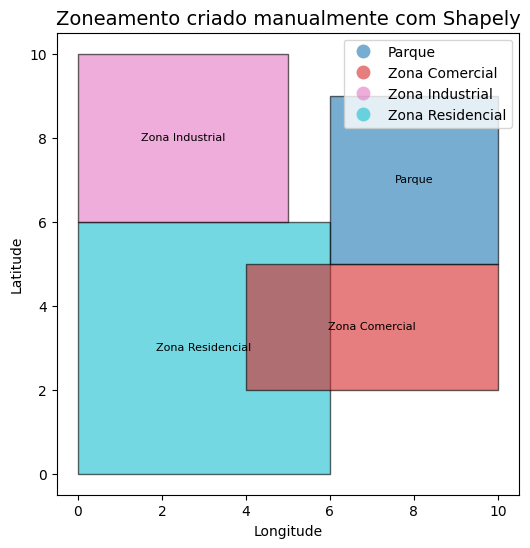

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
zonas.plot(ax=ax,
           column="nome",
           legend=True,
           edgecolor="black",
           alpha=0.6
           )

for idx, row in zonas.iterrows():
  centro = row.geometry.centroid
  ax.text(centro.x, centro.y, row["nome"], ha="center", va="center", fontsize=8)


ax.set_title("Zoneamento criado manualmente com Shapely", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
plt.show()



In [21]:
print("Área de cada zona (em graus²):")
for idx, row in zonas.iterrows():
  print(f"  {row["nome"]}: {row.geometry.area:.2f}")

print("Interseção entre Zona Residencial e Zona Comercial:")
inter = zonas.iloc[0].geometry.intersection(zonas.iloc[1].geometry)
print(f"   Área da interseção: {inter.area:.2f}")


Área de cada zona (em graus²):
  Zona Residencial: 36.00
  Zona Comercial: 18.00
  Zona Industrial: 20.00
  Parque: 16.00
Interseção entre Zona Residencial e Zona Comercial:
   Área da interseção: 6.00


Para unir as geometrias por densidade pode ser usado a função dissolve.

In [22]:
zonas_dissolvidas = zonas[["densidade", "geometry"]].dissolve(by="densidade")
zonas_dissolvidas

,geometry
densidade,
Alta,"POLYGON ((6 0, 6 6, 0 6, 0 0, 6 0))"
Baixa,"POLYGON ((0 6, 5 6, 5 10, 0 10, 0 6))"
Média,"POLYGON ((4 2, 10 2, 10 5, 4 5, 4 2))"
Nula,"POLYGON ((6 5, 10 5, 10 9, 6 9, 6 5))"


### Exercícios

1. Crie um CSV com 10 cidades da sua região, contendo colunas: `nome`, `estado`, `populacao`, `latitude`, `longitude`.
2. Carregue com Pandas e transforme em GeoDataFrame.
3. Atribua o CRS EPSG:4326.
4. Plote os pontos coloridos por estado.
5. Exporte como GeoJSON.

**Desafio extra:** Pesquise qual o código EPSG do sistema UTM da sua região e converta os dados para esse CRS usando `.to_crs()`. O que mudou nos valores de coordenadas? Por quê?

In [23]:
cidades = pd.DataFrame({
    "nome": ["Cascavel", "Guarulhos", "São Bernado do Campo", "Santo André", "Osasco", "São José dos Campos", "Riberirão Preto", "Londrina", "Itarema", "Sobral"],
    "estado": ["PR", "SP", "SP", "SP", "SP", "SP", "SP", "PR", "CE", "CE"],
    "populacao": [372026, 1351284, 842558, 784290, 761441, 729153, 734538, 584465, 46219, 217690],
    "latitude": [-24.9558, -23.4628, -23.6939, -23.6666, -23.5325, -23.1794, -21.1775, -23.3106, -2.9213, -3.6834],
    "longitude": [-53.4553, -46.5333, -46.5650, -46.5322, -46.7917, -45.8869, -47.8103, -51.1628, -39.9147, -40.3497]
})

gdf_cidades = gpd.GeoDataFrame(
    cidades,
    geometry=gpd.points_from_xy(cidades["longitude"], cidades["latitude"])
)

gdf_cidades = gdf_cidades.set_crs("EPSG:4326")
gdf_cidades.insert(0, "id", range(len(gdf_cidades)))
gdf_cidades


,id,nome,estado,populacao,latitude,longitude,geometry
0,0,Cascavel,PR,372026,-24.9558,-53.4553,POINT (-53.4553 -24.9558)
1,1,Guarulhos,SP,1351284,-23.4628,-46.5333,POINT (-46.5333 -23.4628)
2,2,São Bernado do Campo,SP,842558,-23.6939,-46.5650,POINT (-46.565 -23.6939)
3,3,Santo André,SP,784290,-23.6666,-46.5322,POINT (-46.5322 -23.6666)
4,4,Osasco,SP,761441,-23.5325,-46.7917,POINT (-46.7917 -23.5325)
5,5,São José dos Campos,SP,729153,-23.1794,-45.8869,POINT (-45.8869 -23.1794)
6,6,Riberirão Preto,SP,734538,-21.1775,-47.8103,POINT (-47.8103 -21.1775)
7,7,Londrina,PR,584465,-23.3106,-51.1628,POINT (-51.1628 -23.3106)
8,8,Itarema,CE,46219,-2.9213,-39.9147,POINT (-39.9147 -2.9213)
9,9,Sobral,CE,217690,-3.6834,-40.3497,POINT (-40.3497 -3.6834)


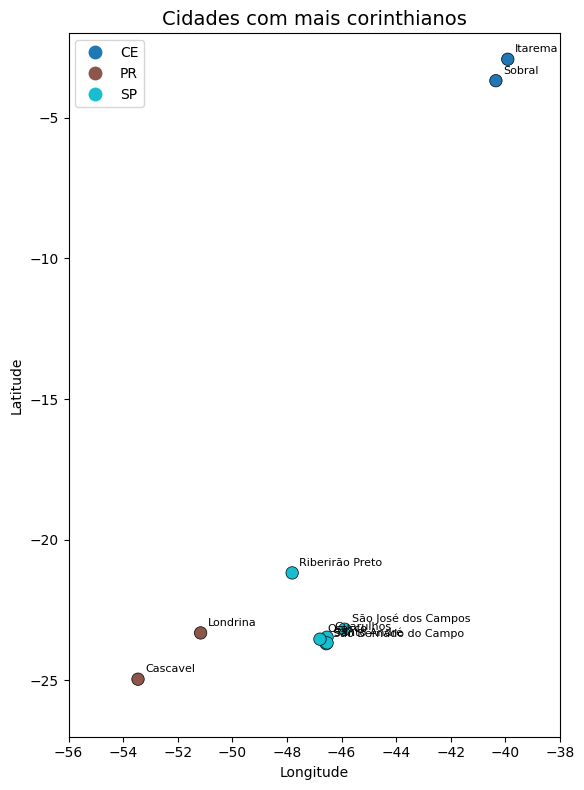

In [24]:
fig, ax = plt.subplots(figsize=(16, 8))

gdf_cidades.plot(
    ax=ax,
    column="estado",
    legend=True,
    markersize=80,
    edgecolor="black",
    linewidth=0.5,
)

for idx, row in gdf_cidades.iterrows():
  ax.annotate(
      f"{row["nome"]}",
      (row.geometry.x, row.geometry.y),
      xytext=(5, 5),
      textcoords="offset points",
      fontsize=8,
  )

ax.set_title("Cidades com mais corinthianos", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.xlim(-56, -38)
plt.ylim(-27, -2)
plt.tight_layout()
plt.show()

<small>*ps: Itarema e Sobral foram liberdades criativas kkkkkkk*<small>

In [26]:
gdf_cidades.to_file("saida/cidades.geojson", driver="GeoJSON")

In [28]:
gdf_cidades = gdf_cidades.to_crs("EPSG:4674")
gdf_cidades

,id,nome,estado,populacao,latitude,longitude,geometry
0,0,Cascavel,PR,372026,-24.9558,-53.4553,POINT (-53.4553 -24.9558)
1,1,Guarulhos,SP,1351284,-23.4628,-46.5333,POINT (-46.5333 -23.4628)
2,2,São Bernado do Campo,SP,842558,-23.6939,-46.5650,POINT (-46.565 -23.6939)
3,3,Santo André,SP,784290,-23.6666,-46.5322,POINT (-46.5322 -23.6666)
4,4,Osasco,SP,761441,-23.5325,-46.7917,POINT (-46.7917 -23.5325)
5,5,São José dos Campos,SP,729153,-23.1794,-45.8869,POINT (-45.8869 -23.1794)
6,6,Riberirão Preto,SP,734538,-21.1775,-47.8103,POINT (-47.8103 -21.1775)
7,7,Londrina,PR,584465,-23.3106,-51.1628,POINT (-51.1628 -23.3106)
8,8,Itarema,CE,46219,-2.9213,-39.9147,POINT (-39.9147 -2.9213)
9,9,Sobral,CE,217690,-3.6834,-40.3497,POINT (-40.3497 -3.6834)


In [29]:
gdf_cidades = gdf_cidades.to_crs("EPSG:31983")
gdf_cidades

,id,nome,estado,populacao,latitude,longitude,geometry
0,0,Cascavel,PR,372026,-24.9558,-53.4553,POINT (-355538.567 7213181.771)
1,1,Guarulhos,SP,1351284,-23.4628,-46.5333,POINT (343393.028 7404412.444)
2,2,São Bernado do Campo,SP,842558,-23.6939,-46.5650,POINT (340434.405 7378786.45)
3,3,Santo André,SP,784290,-23.6666,-46.5322,POINT (343746.727 7381845.889)
4,4,Osasco,SP,761441,-23.5325,-46.7917,POINT (317091.556 7396388.537)
5,5,São José dos Campos,SP,729153,-23.1794,-45.8869,POINT (409227.174 7436343.936)
6,6,Riberirão Preto,SP,734538,-21.1775,-47.8103,POINT (208188.493 7655620.949)
7,7,Londrina,PR,584465,-23.3106,-51.1628,POINT (-130960.033 7408632.925)
8,8,Itarema,CE,46219,-2.9213,-39.9147,POINT (1065880.694 9675823.37)
9,9,Sobral,CE,217690,-3.6834,-40.3497,POINT (1016967.159 9591517.969)
